# Homework 3 in Python

In [38]:
import control as ct
import matplotlib.pyplot as plt
import numpy as np
from math import pi
from pprint import pprint

s = ct.tf("s")

RAD_TO_DEG = 180/pi
DEG_TO_RAD = pi/180

ct.use_matlab_defaults()


## Problem 1


In [39]:
G = 4 / s / (s + 0.5)
p1 = 0
p2 = -0.5

# req
eta = 0.5
wn = 5  # rad/s

wd = wn * np.sqrt(1-eta*eta)
sigma = eta*wn

In [40]:
# Choosing
p_des = -sigma + wd*1j
print(p_des)

(-2.5+4.330127018922193j)


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


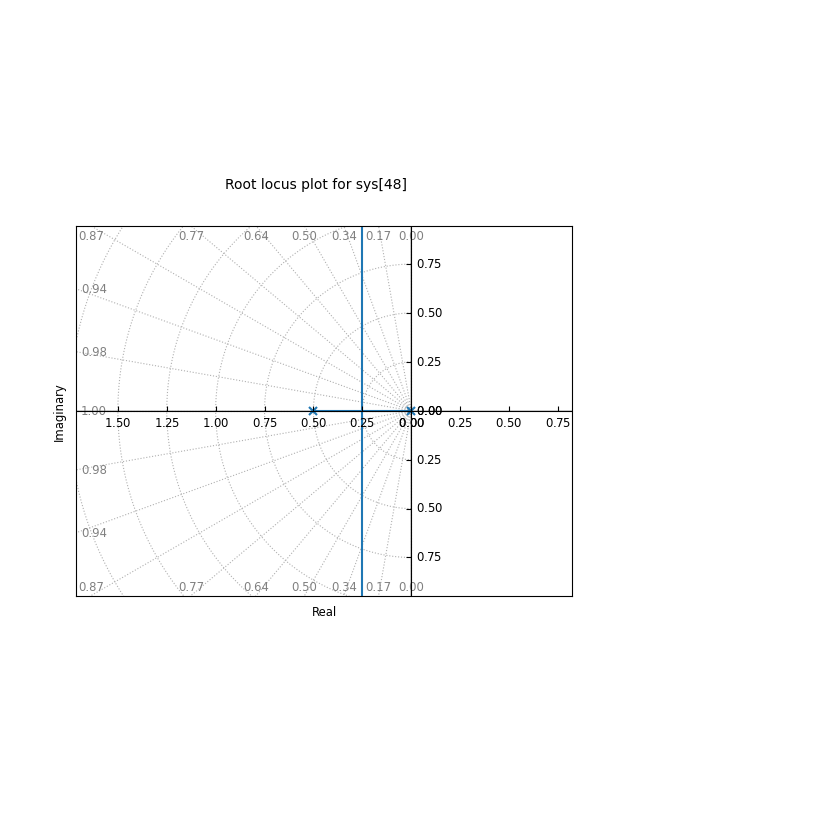

In [41]:
# Cannot choose K s.t. the poles will be at p_des
ct.rlocus(G)

### Kd controller

In [42]:
theta_p1 = np.angle(p_des - p1) * RAD_TO_DEG
theta_p2 = np.angle(p_des - p2) * RAD_TO_DEG
theta_p3 = 180 + theta_p1 + theta_p2 - 360
print(theta_p1)
print(theta_p2)
print(theta_p3)

tan_theta_p3 = np.tan(theta_p3 * DEG_TO_RAD)

z = -np.imag(p_des) / tan_theta_p3 - abs(np.real(p_des))
print(f"{z=}")

print(np.angle(p_des - z) * RAD_TO_DEG)
print(np.angle(np.conj(p_des) - z) * RAD_TO_DEG)

120.00000000000001
114.79128089714489
54.79128089714487
z=np.float64(-5.555555555555558)
54.791280897144865
-54.791280897144865


In [43]:
k_proto = (s - z)
k_pd = 1 / abs(G(p_des)) / abs(k_proto(p_des))
print(k_pd)

K_pd = k_proto * k_pd
L_pd = K_pd * G
L_CL_pd = L_pd / (1 + L_pd)

1.1249999999999996


2 states have been removed from the model
{'Overshoot': 27.01150348258946,
 'Peak': 1.2701150348258952,
 'PeakTime': 0.5023822021077922,
 'RiseTime': 0.2232809787145743,
 'SettlingMax': 1.2701150348258952,
 'SettlingMin': 0.9559618384426941,
 'SettlingTime': 1.5071466063233765,
 'SteadyStateValue': 1.0000000000000004,
 'Undershoot': 0.0}


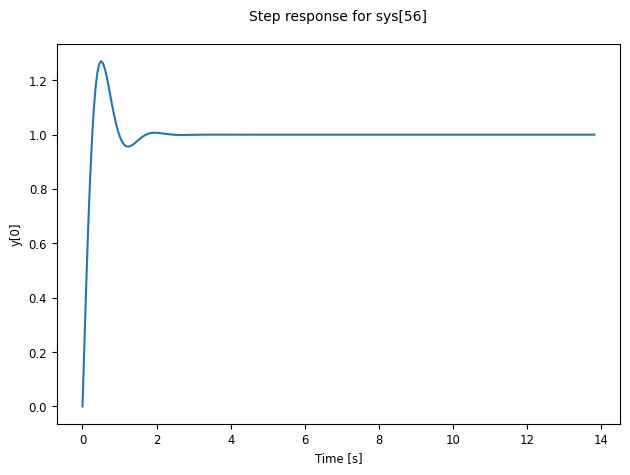

In [44]:
pprint(ct.step_info(ct.minreal(L_CL_pd)))
r = ct.step_response(L_CL_pd)
r.plot()

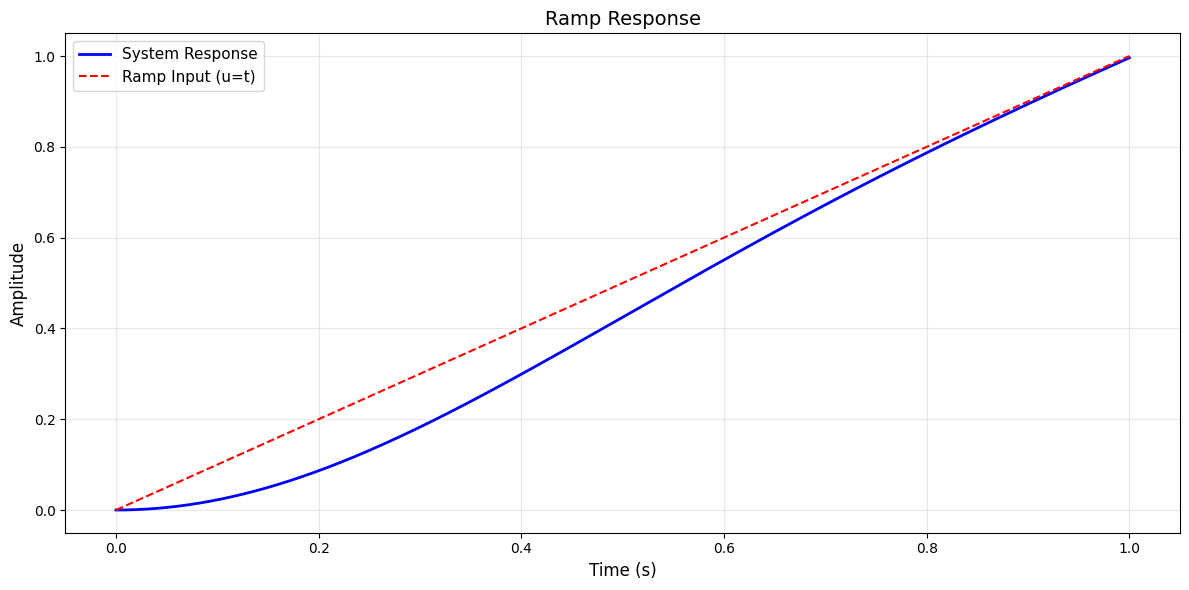

Steady-state error: 0.003903


In [45]:
# Ramp response
t = np.linspace(0, 1, 1000)
ramp_input = t

t, y = ct.forced_response(L_CL_pd, T=t, U=ramp_input)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(t, y, 'b-', linewidth=2, label='System Response')
plt.plot(t, ramp_input, 'r--', linewidth=1.5, label='Ramp Input (u=t)')
plt.grid(True, alpha=0.3)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.title('Ramp Response', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Calculate steady-state error
steady_state_error = t[-1] - y[-1]  # Last index
print(f"Steady-state error: {steady_state_error:.6f}")

## Prob 2

In [46]:
# Plant
G = 1/ s / (s+3) / (s+6)

p1 = 0
p2 = -3
p3 = -6

# Transient specs
ts = 5
mp = 0.17
tp = 2

# Derived
sigma = 4.6/ts
tanTheta = -pi/np.log(mp)
theta = np.arctan(tanTheta) * RAD_TO_DEG
print(f"Theta={theta}º")
wd = pi/tp

Theta=60.5756376628331º


In [47]:
# Desired poles based on those specs
p_des1 = -0.92 + 1.571j
p_des2 = -0.92 - 1.571j

### P controller

In [50]:
K_kp = 1 / abs(G(p_des1))
L_kp = K_kp*G
print(K_kp)

25.233589048668513


In [53]:
# Steady state response
t = np.linspace(0, 1, 1000)
ramp_input = 1

t, y = ct.forced_response(L_kp, T=t, U=ramp_input)

# Calculate steady-state error
steady_state_error = t[-1] - y[-1]  # Last index
print(f"Steady-state error: {steady_state_error:.6f}")


Steady-state error: 0.253116
